# Model Training and Evaluation Setup

In [1]:
import torch

if torch.cuda.is_available():
    print("CUDA is ready")
else:
    print("CUDA is **not** ready.")
    print("You have to start this notebook with docker run --gpus all -p 7777:7777 bertdoc_colbert:latest")
    print("Necessary for this notebook, otherwise there is no training possible.")   

CUDA is ready


This setup defines which data to use for training and testing a model.

There are two standard training and test options.
1. train_specification = ‘1_to_25_80p’ with test_specification = '26_to_50_100p'
2. train_specification = ‘26_to_50_80p’ with test_specification = '1_to_25_100p'

e.g. 1_to_25_80p: _1_to_25 means question block 1, with 80 percent of the data_

In [2]:
train_specification = '1_to_25_80p' # '1_to_25_80p' or '26_to_50_80p'
test_specification = '26_to_50_100p' # '26_to_50_100p' or '1_to_25_100p'

___
--There is a separate notebook for the traceability of the training- and testdata: \_split_train_test_data.ipynb--

# Training

In [3]:
import json

with open(f'training_splits/train_{train_specification}.json', 'r') as file:
    train_data = json.load(file)

model_name = 'new_trained_colbert' # arbitrary
new_model_path = '' # will be used later as path to the model

In [4]:
from ragatouille import RAGTrainer
rag_trainer = RAGTrainer(model_name="ColbertBertDoc", pretrained_model_name="colbert-ir/colbertv2.0", language_code="en")
training_data = rag_trainer.prepare_training_data(
    raw_data=train_data,
    data_out_path=f"{model_name}",            
    mine_hard_negatives=False,
    pairs_with_labels=True,   
    positive_label='1',
    negative_label='0')

In [5]:
new_model_path = rag_trainer.train(batch_size=32,
              nbits=2, # How many bits will the trained model use when compressing indexes
              maxsteps=500000, # Maximum steps hard stop
              use_ib_negatives=False, # Use in-batch negative to calculate loss
              dim=128, # How many dimensions per embedding. 128 is the default and works well.
              learning_rate=5e-6, # Learning rate, small values ([3e-6,3e-5] work best if the base model is BERT-like, 5e-6 is often the sweet spot)
              doc_maxlen=128, # Maximum document length. Because of how ColBERT works, smaller chunks (128-256) work very well.
              use_relu=False, # Disable ReLU -- doesn't improve performance
              warmup_steps="auto", # Defaults to 10%
             )

#> Starting...
nranks = 1 	 num_gpus = 1 	 device=0
{
    "query_token_id": "[unused0]",
    "doc_token_id": "[unused1]",
    "query_token": "[Q]",
    "doc_token": "[D]",
    "ncells": null,
    "centroid_score_threshold": null,
    "ndocs": null,
    "load_index_with_mmap": false,
    "index_path": null,
    "index_bsize": 64,
    "nbits": 2,
    "kmeans_niters": 20,
    "resume": false,
    "pool_factor": 1,
    "clustering_mode": "hierarchical",
    "protected_tokens": 0,
    "similarity": "cosine",
    "bsize": 32,
    "accumsteps": 1,
    "lr": 5e-6,
    "maxsteps": 500000,
    "save_every": 1,
    "warmup": 1,
    "warmup_bert": null,
    "relu": false,
    "nway": 2,
    "use_ib_negatives": false,
    "reranker": false,
    "distillation_alpha": 1.0,
    "ignore_scores": false,
    "model_name": "ColbertBertDoc",
    "query_maxlen": 32,
    "attend_to_mask_tokens": false,
    "interaction": "colbert",
    "dim": 128,
    "doc_maxlen": 128,
    "mask_punctuation": true,
    "che

[Aug 06, 11:16:10] #> Loading the queries from new_trained_colbert/queries.train.colbert.tsv ...
[Aug 06, 11:16:10] #> Got 25 queries. All QIDs are unique.

[Aug 06, 11:16:10] #> Loading collection...
0M 


/usr/local/lib/python3.10/site-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
/usr/local/lib/python3.10/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.10/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


#> LR will use 1 warmup steps and linear decay over 500000 steps.

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input:  What are the risks of metamizol?, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2054,  2024,  1996, 10831,  1997, 18804,  4328,  6844,
         2140,  1029,   102,   103,   103,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')

#>>>    21.9 12.82 		|		 9.079999999999998
[Aug 06, 11:16:54] 0 0.3384697139263153
#>>>    22.21 13.77 		|		 8.440000000000001
[Aug 06, 11:16:54] 1 0.33850692769885066
#>>>    22.8 13.35 		|		 9.450000000000001
[Aug 06, 11:16:54] 2 0.3384324016664326
#>>>    22.37 11.7 		|		 10.670000000000002
[Aug 06, 11:16:54] 3 0.3383454

[rank0]:[W806 11:16:58.603004002 ProcessGroupNCCL.cpp:1496] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


#> Joined...


# Evaluation

In [6]:
import json

json__testdata_colbert = f'test_splits/test_{test_specification}.json'

with open(json__testdata_colbert, 'r') as col_test_file:
    test_set = json.load(col_test_file)

In [7]:
import os
from ragatouille import RAGPretrainedModel

def save_scores(model_name):
    rag = RAGPretrainedModel.from_pretrained(new_model_path) # path is set as return of training

    y_score = []  # score of model
    y_true = []   # score of human

    for document in test_set:
        document_query = document[0]
        document_answer = document[1]
        our_answer = document[2]

        rag.encode([document_answer], verbose=False)
        score = rag.search_encoded_docs(document_query, k=1)
        
        y_score.append(score[0]['score'])
        y_true.append(our_answer)

    scores = list(zip(y_score, y_true))

    output_dir = f"evaluation_area/{model_name}"
    os.makedirs(output_dir, exist_ok=True)

    filename_scores = f"{output_dir}/{test_specification}.json"
    with open(filename_scores, 'w') as json_file:
        json.dump(scores, json_file, indent=4)

save_scores(model_name=model_name)

/usr/local/lib/python3.10/site-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.10/site-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


# ROC

In [8]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [9]:
def get_statistic_scores(model_name, filename_tested):         
    
    filename_scores = f"evaluation_area/{model_name}/{filename_tested}.json"
    with open(filename_scores, "r", encoding="utf-8") as file:
        data_scores = json.load(file)
        y_score = [x[0] for x in data_scores]
        y_true = [x[1] for x in data_scores]
        
    filename_model_info_training =  f"evaluation_area/_trainings_overview.json"
    with open(filename_model_info_training, "r", encoding="utf-8") as trainingfile:
        data_info_model = json.load(trainingfile)     
        for model in data_info_model:
            if model == model_name:
                model_info_training = data_info_model[model_name] 
                break
            else:
                model_info_training = train_specification
    
    return y_score, y_true, model_info_training

In [10]:
def build_roc_curve(model_names, filename_tested, colors, labels=True):
    plt.figure()

    legend_entries = []

    for model in model_names:
        y_score, y_true, model_info_training = get_statistic_scores(model_name = model, filename_tested=filename_tested)
        
        fpr, tpr, thresholds = roc_curve(y_true=y_true, y_score=y_score, pos_label='1')
        roc_auc = auc(fpr,tpr)
        
        color = colors.pop()        
        legend_entries.append(f'ROC {model} (area = {roc_auc:.2f}) {model_info_training}')
        
        plt.plot(fpr, tpr, color=color, lw=2, label=f'ROC {model} (area = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    
    if labels == True:
        plt.title(f'Testdata: {filename_tested}')        
        plt.figtext(0.5, -0.1, "\n".join(legend_entries), wrap=True, horizontalalignment='center', fontsize=10)        
        plt.savefig(f"roc_{model}-{filename_tested}.svg", format="svg", bbox_inches="tight")
    else:        
        plt.savefig(f"roc_{model}-{filename_tested[:-8]}.svg", format="svg", bbox_inches="tight")
    
    plt.show()

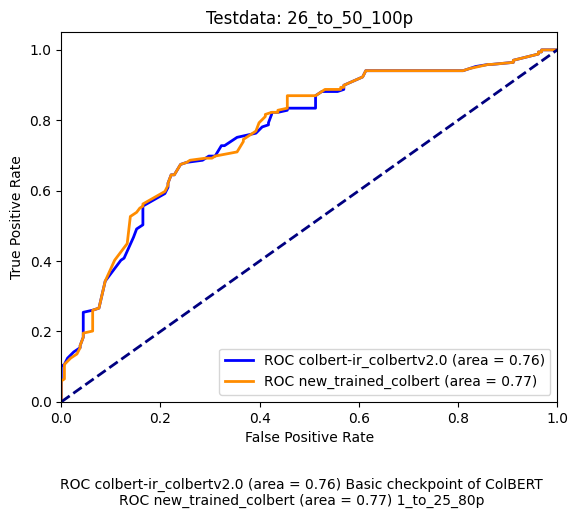

In [11]:
build_roc_curve(model_names = ['colbert-ir_colbertv2.0', model_name], 
                filename_tested = test_specification,
                colors=['red', 'darkorange', 'blue'])

# Boxplot

In [12]:
import seaborn as sns
import numpy as np

# Prepare data for the boxplot
# y_bool = [0, 1, 0, 1, 1, 0, 1, 0, 1, 0]
# y_scores = [0.2, 0.8, 0.4, 0.9, 0.85, 0.1, 0.6, 0.3, 0.75, 0.05]

def build_boxplot(model, filename_tested, ylimbot=None, ylimtop=None):    

    y_score, y_true, model_info_training = get_statistic_scores(model_name = model,                                                                 
                                                                filename_tested=filename_tested)    
    
    y_true = np.array([int(i) for i in y_true])
    y_score = np.array(y_score)
    scores_by_class = [y_score[y_true == 0], y_score[y_true == 1]] 
      
    plt.figure(figsize=(0.5, 6))
    sns.boxplot(data=scores_by_class)
    plt.xticks([0, 1], labels=['Irrelevant', 'Relevant'], rotation=45, ha='right', fontsize=11)    
    plt.ylabel('Predicted Scores') 
    if ylimbot != None:      
        plt.ylim(ylimbot, ylimtop)
    plt.title(model, fontsize=10, fontweight = 'bold', pad=15)
    plt.figtext(1, -0.2, f'Tested:  {filename_tested} \n\n Trained: {model_info_training}', wrap=True, horizontalalignment='center', fontsize=10)
    plt.savefig(f"bp_{model}-{filename_tested}.svg", format="svg", bbox_inches="tight")
    plt.show()

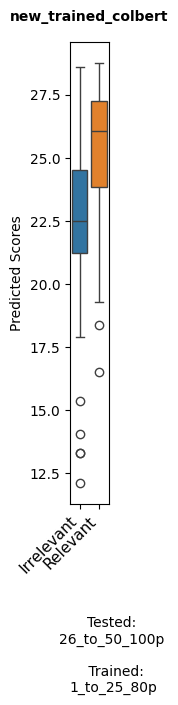

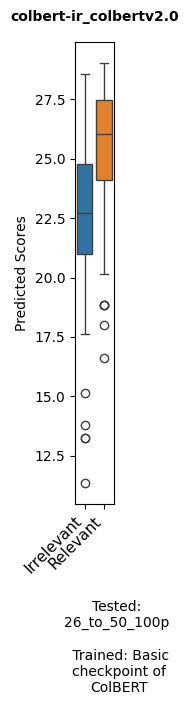

In [13]:
build_boxplot(model_name, test_specification)
build_boxplot('colbert-ir_colbertv2.0', test_specification)